In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
graak = pd.read_csv("../data/combine/graank_combine.csv")

In [4]:
graak = graak.drop('Unnamed: 0', axis=1)

In [5]:
df  = graak[graak['sup_min']>= 0.3]

In [6]:
df

,execution_time,sup_min,number of patterns,memory_usage,dataset,algorithm
8,9.638912,0.30,150,50.364258,HCV,Graank
9,9.240743,0.34,120,39.067383,HCV,Graank
10,8.967299,0.38,94,30.809570,HCV,Graank
11,8.862499,0.40,94,30.036133,HCV,Graank
12,7.565296,0.50,48,20.431641,HCV,Graank
...,...,...,...,...,...,...
125,8.494632,0.60,112,38.968750,PCA Chickenpox,Graank
126,7.503642,0.70,44,19.597656,PCA Chickenpox,Graank
127,7.109069,0.80,0,4.356445,PCA Chickenpox,Graank
128,7.121989,0.90,0,4.856445,PCA Chickenpox,Graank


In [7]:
df

,execution_time,sup_min,number of patterns,memory_usage,dataset,algorithm
8,9.638912,0.30,150,50.364258,HCV,Graank
9,9.240743,0.34,120,39.067383,HCV,Graank
10,8.967299,0.38,94,30.809570,HCV,Graank
11,8.862499,0.40,94,30.036133,HCV,Graank
12,7.565296,0.50,48,20.431641,HCV,Graank
...,...,...,...,...,...,...
125,8.494632,0.60,112,38.968750,PCA Chickenpox,Graank
126,7.503642,0.70,44,19.597656,PCA Chickenpox,Graank
127,7.109069,0.80,0,4.356445,PCA Chickenpox,Graank
128,7.121989,0.90,0,4.856445,PCA Chickenpox,Graank


In [8]:
df['Status'] = df['dataset'].apply(lambda x: 'pca graank' if str(x).startswith('PCA') else 'graank')
df['dataset'] = df['dataset'].str.replace(r'^PCA', '', regex=True).str.strip()


/tmp/ipykernel_454197/3553724662.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Status'] = df['dataset'].apply(lambda x: 'pca graank' if str(x).startswith('PCA') else 'graank')
/tmp/ipykernel_454197/3553724662.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dataset'] = df['dataset'].str.replace(r'^PCA', '', regex=True).str.strip()


In [9]:
df['dataset'] = df['dataset'].apply(lambda x: "Air Quality" if x == 'Air Quailty' else x)

/tmp/ipykernel_454197/826042045.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dataset'] = df['dataset'].apply(lambda x: "Air Quality" if x == 'Air Quailty' else x)


In [10]:
df[df['dataset'] =='Air Quailty']

,execution_time,sup_min,number of patterns,memory_usage,dataset,algorithm,Status


In [11]:
filenames = ['HCV', 'Air Quality', 'Cargo 2000', 'Chickenpox']

In [12]:
for i, file in enumerate(filenames):
    print(i)

0
1
2
3


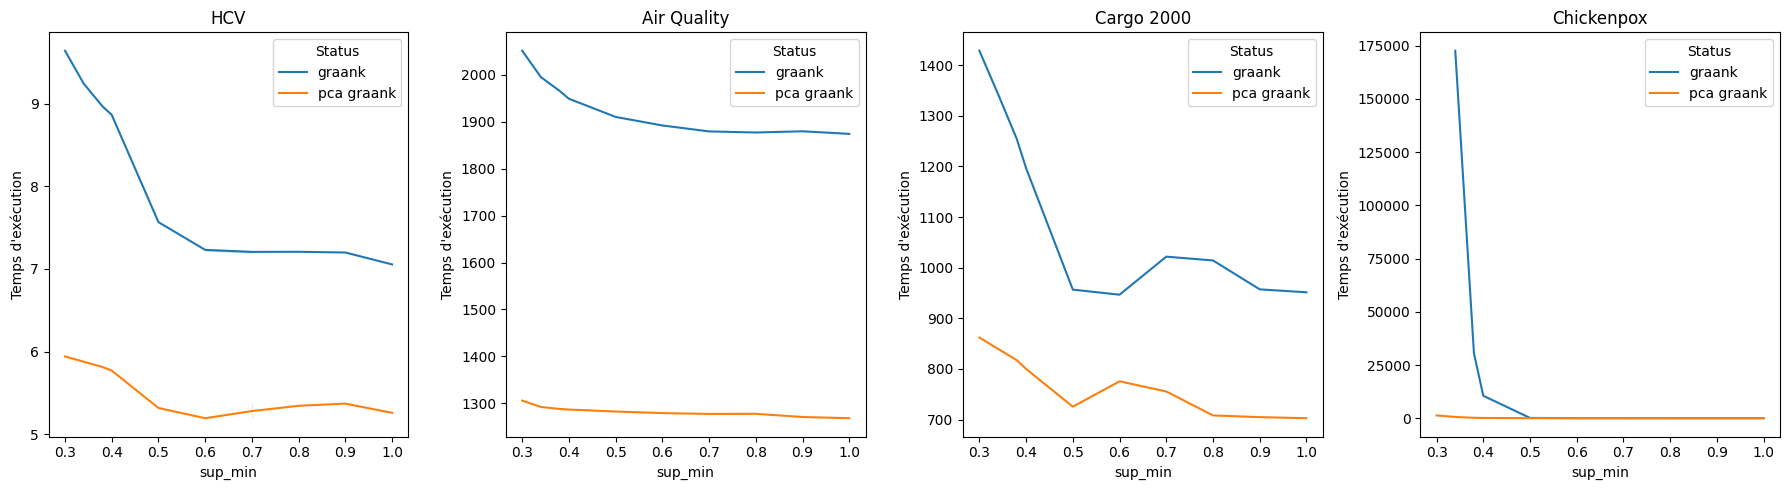

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
datasets = df.dataset.unique()

for i, file in enumerate(filenames):
    df_tmp = df[df['dataset'] == file]

    sns.lineplot(data=df_tmp, x='sup_min', y='execution_time', ax=axes[i], hue='Status')
    axes[i].set_title(file)
    axes[i].set_ylabel("Temps d'exécution")

# Ajustement
plt.tight_layout()
plt.show()


In [14]:

def plot_metrics(df, filenames, algorithme_name ='Graank',col_supp ='sup_min', col_time ='execution_time', col_memory='memory_usage',col_candidate = 'number of patterns',  n_rows=3, n_cols=4, figsize=(20, 8)):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Si axes est 2D, sinon convertir en 2D pour uniformiser
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    if n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    print(df[col_supp].unique())
    for i, file in enumerate(filenames):

        
        df_tmp = df[df['dataset'] == file]

        sns.lineplot(data=df_tmp, x=col_supp, y=col_time, hue='Status', ax=axes[0, i])
        axes[0, i].set_title(f"{file} - Tme")
        axes[0, i].set_xlabel("Min sup")
        axes[0, i].set_ylabel("Time (s)")
        
        sns.lineplot(data=df_tmp, x=col_supp, y=col_memory, hue='Status', ax=axes[1, i])
        axes[1, i].set_title(f"{file} - Memory")
        axes[1, i].set_xlabel("Min sup")
        axes[1, i].set_ylabel("Memory (KB)")

        sns.lineplot(data=df_tmp, x=col_supp, y=col_candidate, hue='Status', ax=axes[2, i])
        axes[2, i].set_title(f"{file} - Candidats")
        axes[2, i].set_xlabel("Min sup")
        axes[2, i].set_ylabel("# candidats")

    plt.suptitle(algorithme_name, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"../images_conf/{algorithme_name}_fr_metrics.eps")
    plt.show()


In [15]:
df['dataset'].unique()

array(['HCV', 'Air Quality', 'Cargo 2000', 'Chickenpox'], dtype=object)

In [18]:
df

,execution_time,sup_min,number of patterns,memory_usage,dataset,algorithm,Status
8,9.638912,0.30,150,50.364258,HCV,Graank,graank
9,9.240743,0.34,120,39.067383,HCV,Graank,graank
10,8.967299,0.38,94,30.809570,HCV,Graank,graank
11,8.862499,0.40,94,30.036133,HCV,Graank,graank
12,7.565296,0.50,48,20.431641,HCV,Graank,graank
...,...,...,...,...,...,...,...
125,8.494632,0.60,112,38.968750,Chickenpox,Graank,pca graank
126,7.503642,0.70,44,19.597656,Chickenpox,Graank,pca graank
127,7.109069,0.80,0,4.356445,Chickenpox,Graank,pca graank
128,7.121989,0.90,0,4.856445,Chickenpox,Graank,pca graank


[0.3  0.34 0.38 0.4  0.5  0.6  0.7  0.8  0.9  1.  ]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


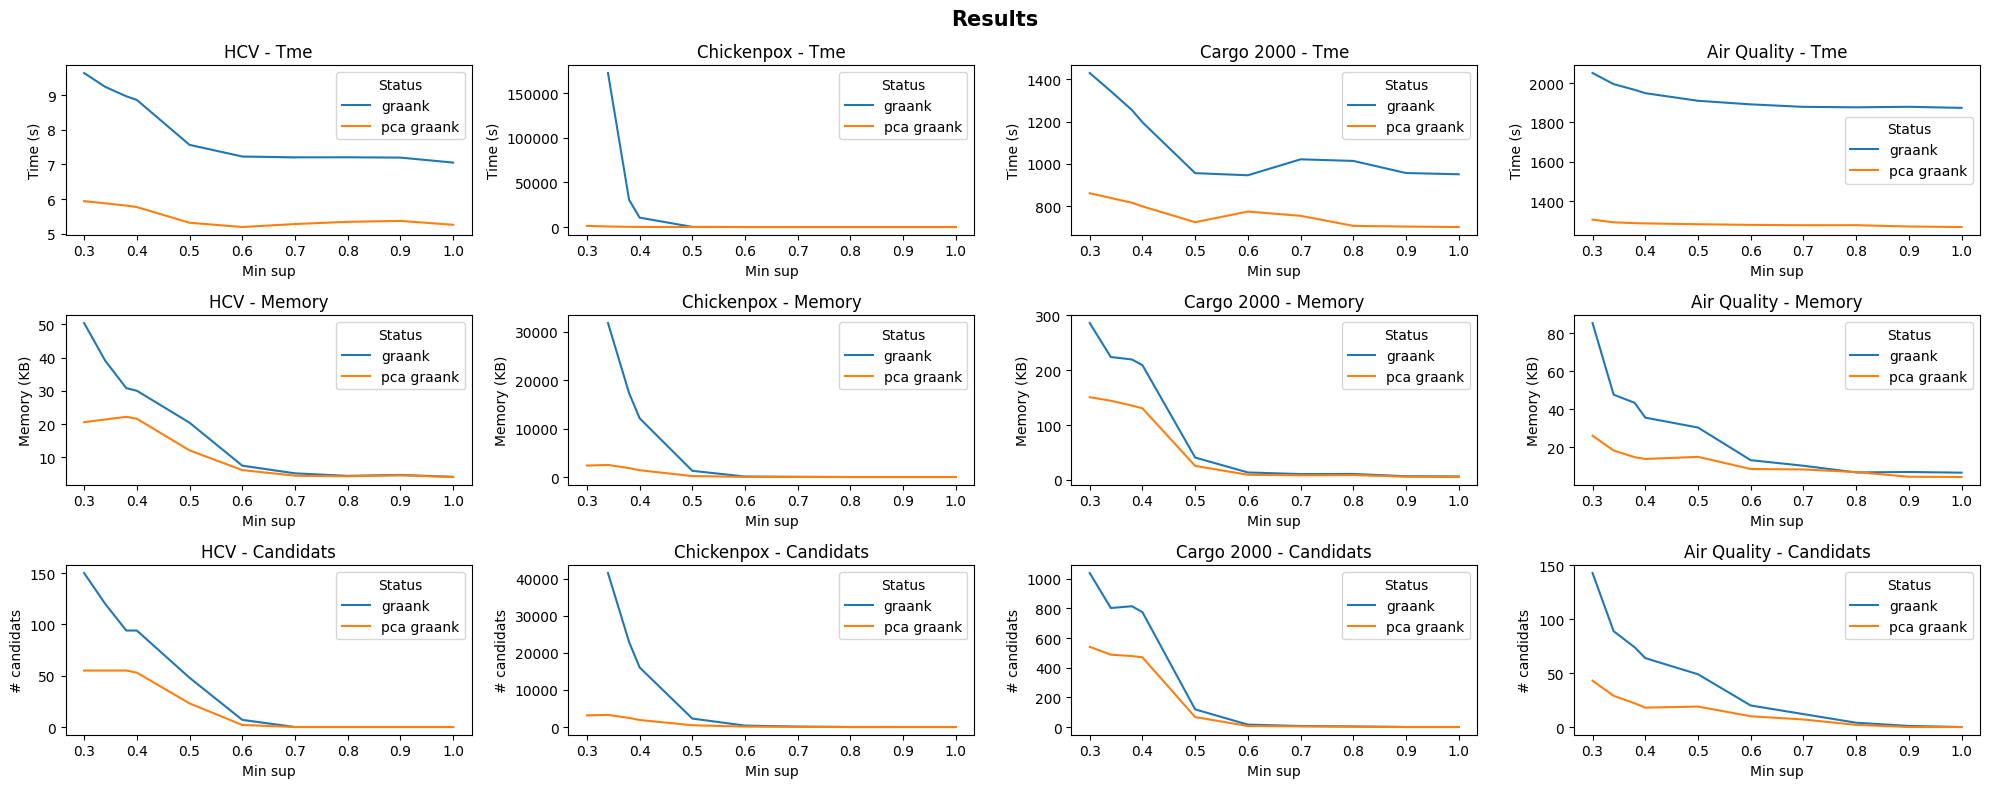

In [16]:
filenames = ['HCV','Chickenpox', 'Cargo 2000', 'Air Quality']
plot_metrics(df, filenames,algorithme_name='Results', n_rows=3, n_cols=4, figsize=(20,8))


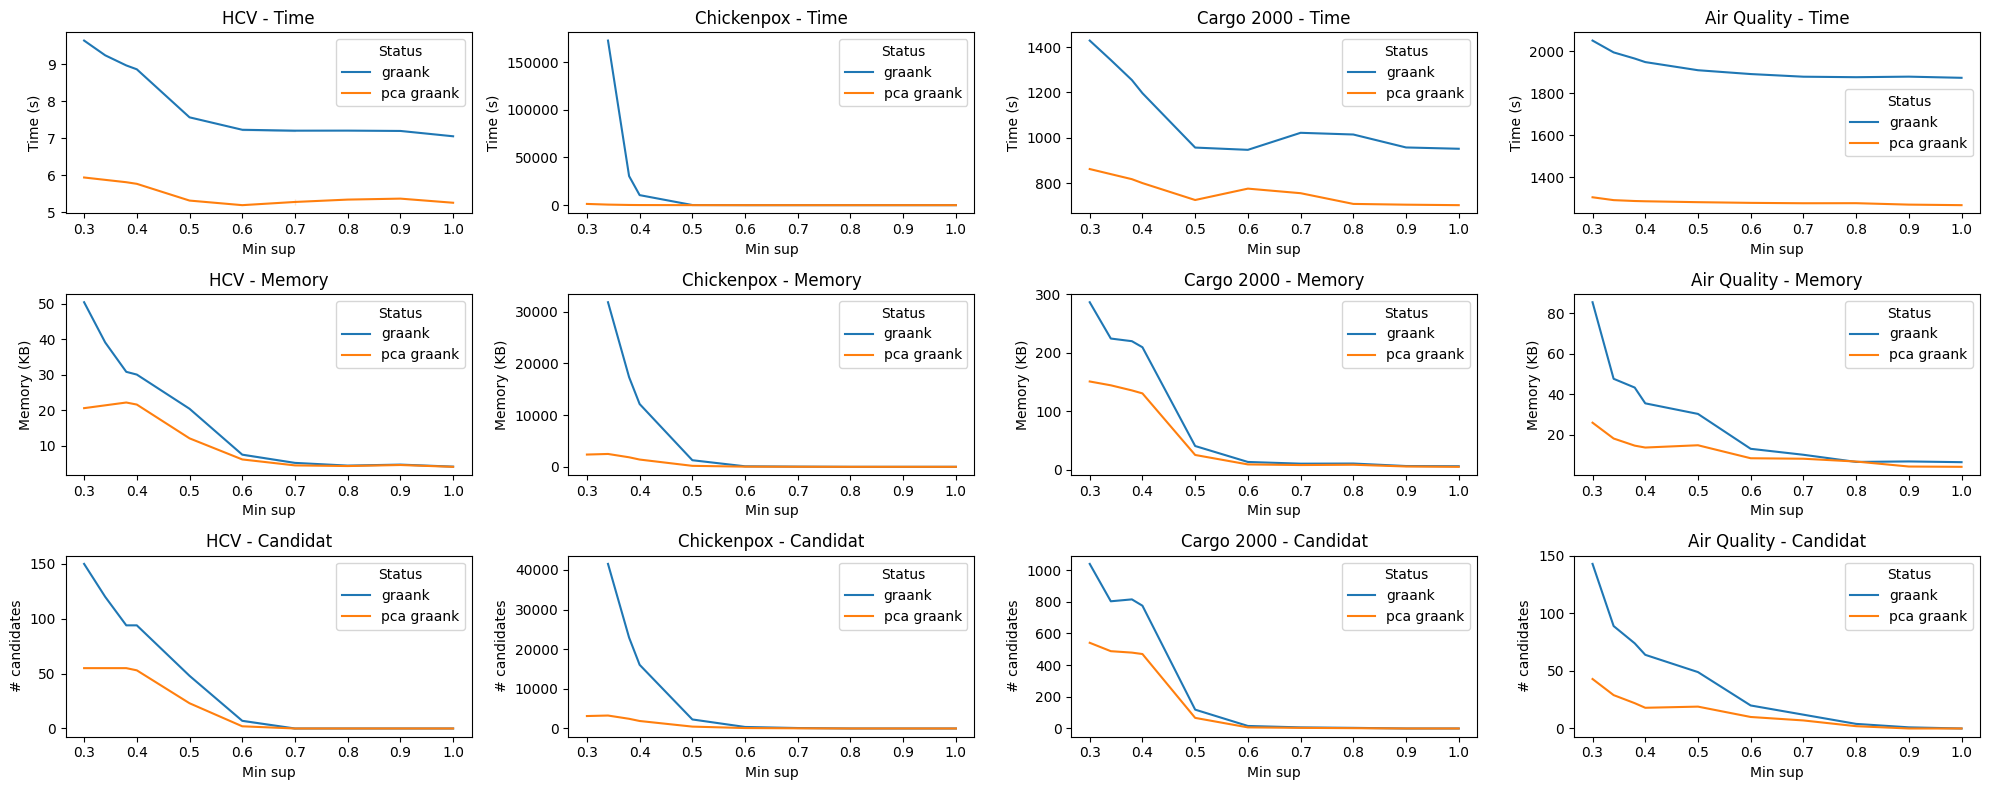

In [17]:
fig, axes = plt.subplots(3, 4, figsize=(20, 8))
datasets = df.dataset.unique()

for i, file in enumerate(filenames):
    df_tmp = df[df['dataset'] == file]

    # Ligne 1 : temps
    sns.lineplot(data=df_tmp, x='sup_min', y='execution_time', hue='Status', ax=axes[0, i])
    axes[0, i].set_title(f"{file} - Time")
    axes[0, i].set_xlabel("Min sup")
    axes[0, i].set_ylabel("Time (s)")
    axes[0, i].set_xlabel("Min sup")
    # Ligne 2 : mémoire
    sns.lineplot(data=df_tmp, x='sup_min', y='memory_usage', hue='Status', ax=axes[1, i])
    axes[1, i].set_title(f"{file} - Memory")
    axes[1, i].set_ylabel("Memory (KB)")
    axes[1, i].set_xlabel("Min sup")
    
    
    sns.lineplot(data=df_tmp, x='sup_min', y='number of patterns', hue='Status', ax=axes[2, i])
    axes[2, i].set_title(f"{file} - Candidat")
    axes[2, i].set_ylabel("# candidates")
    axes[2, i].set_xlabel("Min sup")

plt.tight_layout()
plt.show()


In [20]:
df.columns

Index(['execution_time', 'sup_min', 'number of patterns', 'memory_usage',
       'dataset', 'algorithm', 'Status'],
      dtype='object')

In [28]:
df2 = pd.DataFrame(columns=['Dataset', 'Algorithm', 'Support', 'Run-time (s)', 'Memory (KiB)',
       'Nb Motifs', 'Supports motifs', 'Motifs détectés'])

In [30]:
df2 =  df[ ['dataset', 'Status', 'sup_min', 'execution_time', 'memory_usage', 'number of patterns', 'Status','Status']]

In [32]:
df2.columns = ['Dataset', 'Algorithm', 'Support', 'Run-time (s)', 'Memory (KiB)',
       'Nb Motifs', 'Supports motifs', 'Motifs détectés']

In [33]:
df2

,Dataset,Algorithm,Support,Run-time (s),Memory (KiB),Nb Motifs,Supports motifs,Motifs détectés
8,HCV,graank,0.30,9.638912,50.364258,150,graank,graank
9,HCV,graank,0.34,9.240743,39.067383,120,graank,graank
10,HCV,graank,0.38,8.967299,30.809570,94,graank,graank
11,HCV,graank,0.40,8.862499,30.036133,94,graank,graank
12,HCV,graank,0.50,7.565296,20.431641,48,graank,graank
...,...,...,...,...,...,...,...,...
125,Chickenpox,pca graank,0.60,8.494632,38.968750,112,pca graank,pca graank
126,Chickenpox,pca graank,0.70,7.503642,19.597656,44,pca graank,pca graank
127,Chickenpox,pca graank,0.80,7.109069,4.356445,0,pca graank,pca graank
128,Chickenpox,pca graank,0.90,7.121989,4.856445,0,pca graank,pca graank


In [ ]:
df2['Algorithm'] = np.where(df2['Algorithm'] == 'ga', "GA-GRAANK", "PCA-GRAANK")

In [34]:
df2.Algorithm = np.where(df2['Algorithm'] =="graank", "GRAANK", "PCA-GRAANK"  )

/tmp/ipykernel_454197/324734056.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.Algorithm = np.where(df2['Algorithm'] =="graank", "GRAANK", "PCA-GRAANK"  )


In [37]:
df2['Supports motifs'] = 0 
df2['Motifs détectés'] = ""

/tmp/ipykernel_454197/4226907276.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Supports motifs'] = 0
/tmp/ipykernel_454197/4226907276.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Motifs détectés'] = ""


In [39]:
df2.to_csv("result_pca.csv", index=False)